In [32]:
import numpy as np
import matplotlib.pyplot as plt

Running 10% sparsity...
Running 5% sparsity...
Running 1% sparsity...
Running 10% sparsity...
Running 5% sparsity...
Running 1% sparsity...
Running 10% sparsity...
Running 5% sparsity...
Running 1% sparsity...
Running 10% sparsity...
Running 5% sparsity...
Running 1% sparsity...


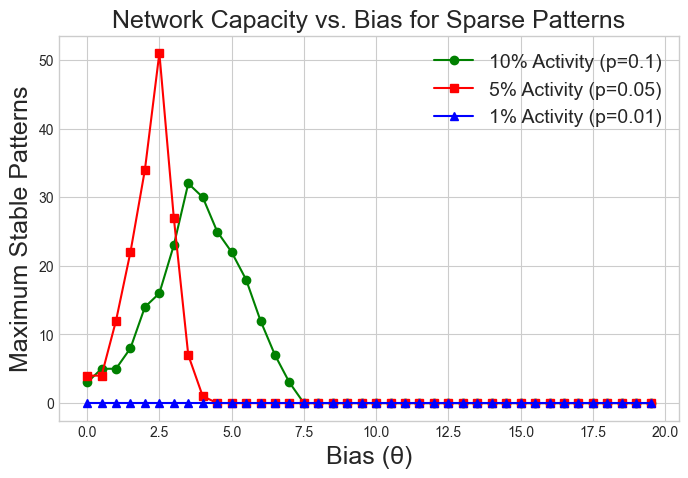

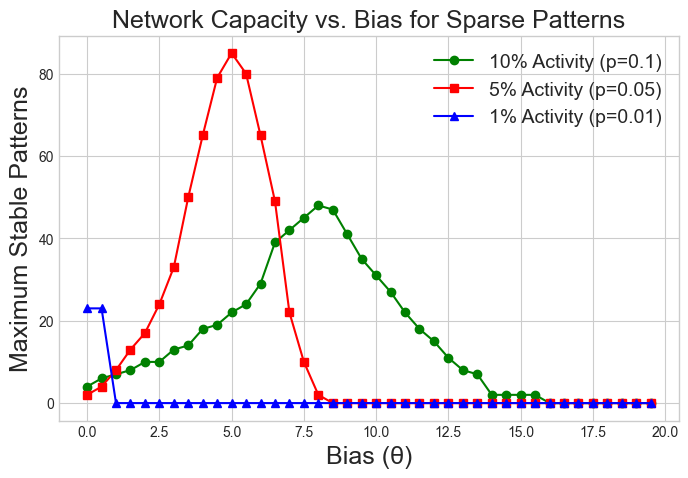

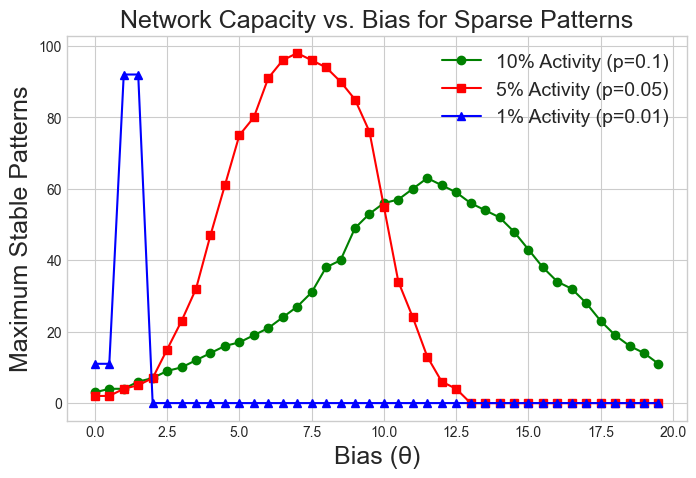

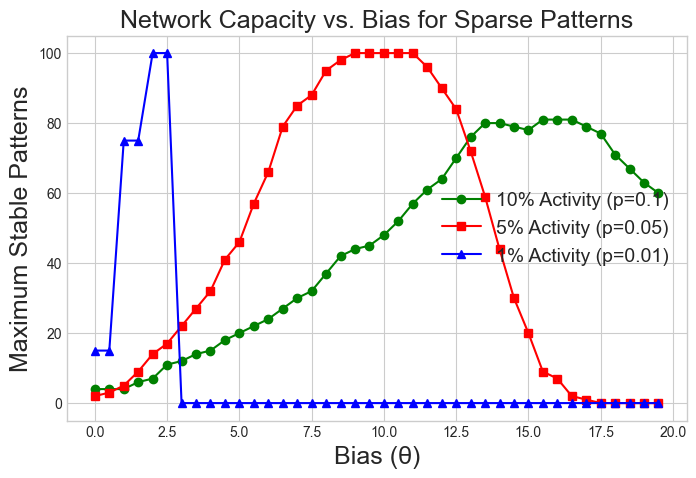

In [55]:
def memorize(x, p):
    prepared_x = x - p
    result = np.outer(prepared_x, prepared_x)
    np.fill_diagonal(result, 0)
    return result

def recall(state, w, b):
    a = state @ w
    a = a-b
    result = 0.5+0.5*np.sign(a)
    return result


def generate_patterns(num_patterns, p, num_neurons=100):
    np.random.seed(47)
    num_ones = int(num_neurons * p) 
    base_pattern = np.zeros(num_neurons)
    base_pattern[:num_ones] = 1
    patterns_set = set()  
    patterns = []
    while len(patterns) < num_patterns:
        shuffled = np.random.permutation(base_pattern)
        pattern_tuple = tuple(shuffled)
        if pattern_tuple not in patterns_set:
            patterns_set.add(pattern_tuple)
            patterns.append(shuffled)
    return np.array(patterns)


def run(p,num_patterns, num_neurons, bias):
    patterns = generate_patterns(num_patterns, p, num_neurons)
    emperical_p = np.sum(patterns)/np.size(patterns)
    assert p == emperical_p, "p is not the same"
    max_stable_patterns = []
    for b in bias:
        w = np.zeros((num_neurons, num_neurons))
        stable_count = 0
        for i in range(len( patterns)):
            w += memorize(patterns[i], p)
            current_stable = 0
            for j in range(i + 1):
                result = recall(patterns[j], w, b)
                if np.array_equal(patterns[j], result):
                    current_stable += 1
            if current_stable > stable_count:
                stable_count = current_stable
        max_stable_patterns.append(stable_count)
    return max_stable_patterns


def run_experiment(num_patterns=50, num_neurons=100):
    biases = np.arange(0,20,0.5)
    print("Running 10% sparsity...")
    activity_10 = run(0.1, num_patterns, num_neurons, biases)
    print("Running 5% sparsity...")
    activity_5 = run(0.05, num_patterns, num_neurons, biases)
    print("Running 1% sparsity...")
    activity_1 = run(0.01, num_patterns, num_neurons, biases)

    plt.style.use('seaborn-v0_8-whitegrid')

    fig, axes = plt.subplots(figsize=(8,5))
    axes.plot(biases, activity_10, label='10% Activity (p=0.1)', c="g", marker='o')
    axes.plot(biases, activity_5, label='5% Activity (p=0.05)', c="r", marker='s')
    axes.plot(biases, activity_1, label='1% Activity (p=0.01)', c="b", marker='^')

    axes.set_title('Network Capacity vs. Bias for Sparse Patterns', fontsize=18)
    axes.set_xlabel('Bias (\u03b8)', fontsize=18)
    axes.set_ylabel('Maximum Stable Patterns', fontsize=18)
    axes.legend(fontsize=14)


run_experiment(100, 100)
run_experiment(100, 200)
run_experiment(100, 300)
run_experiment(100, 400)



